The MNIST dataset is a classic dataset for image classification, containing 70,000 grayscale images of handwritten digits (0-9).

Importing Necessary Libraries

In [19]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [ ]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
print(y_test)

[7 2 1 ... 4 5 6]


In [6]:

import numpy as np
indices = np.random.randint(0, x_train.shape[0], size=16)

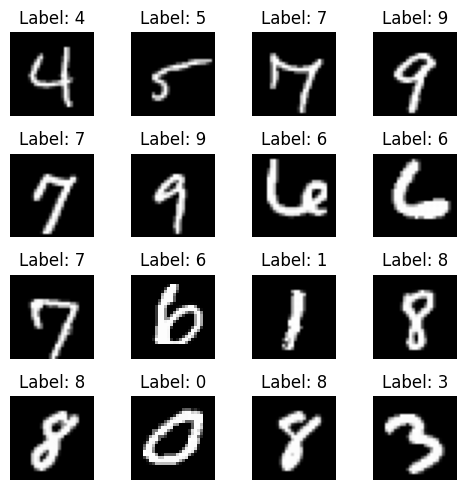

In [7]:

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = x_train[indices[i]]
    label = y_train[indices[i]]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:

img_rows, img_cols = 28, 28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)


**Purpose of Reshaping**
The goal of this reshaping is to transform the data into a 4-dimensional array, which is the standard format for image data in CNNs. The dimensions represent:

Number of samples: The total number of images in the dataset.

Image height: The height of each image in pixels.

Image width: The width of each image in pixels.

Number of channels: The number of color channels in the image.

Example:If you have 60000 images of size 28x28 pixels and they are grayscale, the original shape of x_train would be (60000, 28, 28). After reshaping, it becomes (60000, 28, 28, 1).

**Why is this necessary?**

CNNs are designed to process data in this format. By reshaping the data, we ensure that it's compatible with the CNN's input layer.

**Code description:**
x_train: This is the variable holding the training data.

reshape(): This is a NumPy function to change the shape of an array without changing its data.

x_train.shape[0]: This part extracts the number of samples in the training data.

img_rows: The number of rows in each image.

img_cols: The number of columns in each image.

1: This indicates the number of channels in the image. For grayscale images, it's 1, while for color images, it would be 3 (RGB).

In [9]:
x_train.shape


(60000, 28, 28, 1)

In [10]:

x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [12]:
print(y_test)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [13]:

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:

model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**Categorical cross-entropy** is a loss function used in machine learning for multi-class classification problems. It measures the difference between the true class distribution (the label) and the predicted probability distribution.

**How it works:**

Softmax Activation: The model outputs a vector of values, one for each possible class. These values are passed through a softmax function to convert them into probabilities that sum up to 1.

Cross-Entropy Calculation: The cross-entropy loss is calculated by comparing the predicted probability distribution with the true class distribution (one-hot encoded). The goal is to minimize this loss, which means the model should learn to predict probabilities closer to the true class.

**Adam: An Optimization Algorithm**

Adam is a popular optimization algorithm used in machine learning, especially for training neural networks. It combines the best aspects of two other optimization algorithms: AdaGrad and RMSprop.

How Adam Works:

Adaptive Learning Rates: Adam adapts the learning rate for each parameter individually, which helps accelerate training and improve performance.
Momentum: It incorporates momentum to help the algorithm escape local minima.
Bias Correction: To counteract the initial bias of the estimates, Adam includes bias correction mechanisms.

In [15]:

history=model.fit(x_train, y_train, batch_size=128, epochs=10, verbose=1, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9347 - loss: 0.2269 - val_accuracy: 0.9750 - val_loss: 0.0848
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9792 - loss: 0.0710 - val_accuracy: 0.9785 - val_loss: 0.0614
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9854 - loss: 0.0484 - val_accuracy: 0.9834 - val_loss: 0.0493
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9891 - loss: 0.0367 - val_accuracy: 0.9850 - val_loss: 0.0464
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9921 - loss: 0.0272 - val_accuracy: 0.9850 - val_loss: 0.0444
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9936 - loss: 0.0215 - val_accuracy: 0.9854 - val_loss: 0.0454
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9947 - loss: 0.0170 - val_accuracy: 0.9852 - val_loss: 0.0459
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9964 - loss: 0.0122 - v

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,387,926 (5.29 MB)

In [17]:

test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9868 - loss: 0.0423
Test accuracy: 0.9868000149726868


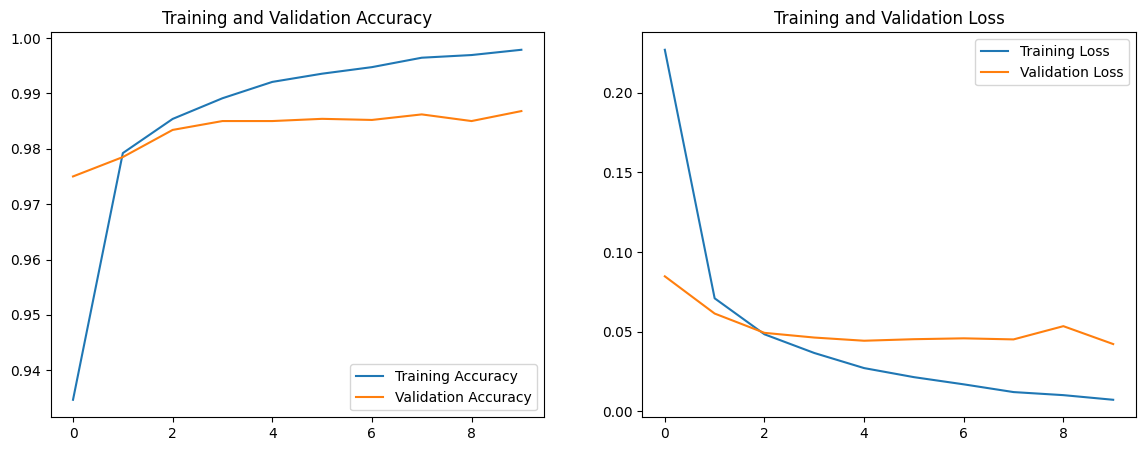

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()